# Baseline 3 – Truy xuất bằng TF-IDF trên Tiêu đề

**Mục tiêu:** Vector hóa cột `title` bằng `TfidfVectorizer`, tính **Cosine Similarity**, đánh giá trên **500 ảnh** (protocol giống Baseline 1 & 2).


## 1. Import thư viện


In [15]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')

DATA_DIR  = '../data/raw/'
CSV_PATH  = os.path.join(DATA_DIR, 'train.csv')
PROCESSED = '../data/processed/'
RESULTS   = '../results/'
os.makedirs(RESULTS, exist_ok=True)

print('Import thư viện thành công!')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


Import thư viện thành công!


**Nhận xét:** Baseline văn bản — bỏ qua pixel, chỉ dựa tên sản phẩm.


## 2. Tập gallery 500 ảnh (cùng Baseline 1)


In [16]:
subset_path = os.path.join(PROCESSED, 'subset.csv')
if os.path.exists(subset_path):
    source_df = pd.read_csv(subset_path)
    print(f'Đã load subset.csv: {len(source_df):,} ảnh')
else:
    df_full = pd.read_csv(CSV_PATH)
    counts = df_full['label_group'].value_counts()
    df_loc = df_full[df_full['label_group'].isin(counts[counts >= 2].index)].copy()
    parts = []
    for _, grp in df_loc.groupby('label_group'):
        parts.append(grp.sample(min(len(grp), 3), random_state=42))
    source_df = pd.concat(parts, ignore_index=True)
    source_df = source_df.sample(min(5000, len(source_df)), random_state=42).reset_index(drop=True)
    print(f'Đã tạo subset tạm: {len(source_df):,} ảnh')

nhom_du_anh = source_df.groupby('label_group').filter(lambda x: len(x) >= 2)
parts = []
for _, grp in nhom_du_anh.groupby('label_group'):
    parts.append(grp.sample(min(len(grp), 2), random_state=42))
candidate_df = pd.concat(parts, ignore_index=True)
candidate_df = candidate_df.sample(min(500, len(candidate_df)), random_state=42).reset_index(drop=True)

nhom_counts = candidate_df['label_group'].value_counts()
print(f'candidate_df: {len(candidate_df):,} ảnh, {candidate_df["label_group"].nunique():,} nhóm')
print(f'Nhóm có 2+ ảnh (query tìm được): {(nhom_counts >= 2).sum():,} nhóm')


Đã load subset.csv: 5,000 ảnh
candidate_df: 500 ảnh, 401 nhóm
Nhóm có 2+ ảnh (query tìm được): 99 nhóm


**Nhận xét:** Gallery trùng notebook pHash/ResNet để so sánh công bằng.


## 3. TF-IDF + Cosine Similarity

- `TfidfVectorizer`: unigram + bigram, tối đa 5000 feature.
- Cosine similarity cao → tiêu đề gần nghĩa.
- Đường chéo = -1 để **loại self-retrieval**.


In [17]:
titles = candidate_df['title'].fillna('').astype(str)
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=1)
tfidf_matrix = vectorizer.fit_transform(titles)

sim_matrix = cosine_similarity(tfidf_matrix).astype(np.float32)
np.fill_diagonal(sim_matrix, -1)

print(f'Số chiều TF-IDF: {tfidf_matrix.shape[1]:,}')
print(f'Ma trận similarity: {sim_matrix.shape}')


Số chiều TF-IDF: 5,000
Ma trận similarity: (500, 500)


**Nhận xét:** Tiêu đề Shopee hay chứa từ khóa marketing chung → dễ trùng từ nhưng khác sản phẩm thật (`label_group`).


## 4. Demo Top-5 theo tiêu đề


In [18]:
query_idx = 0
top5_idx = np.argsort(-sim_matrix[query_idx])[:5]
q_group = candidate_df['label_group'].iloc[query_idx]

print(f'Tiêu đề query: {titles.iloc[query_idx][:100]}')
print(f'Nhóm: {q_group}\n')
for rank, j in enumerate(top5_idx, 1):
    dung = candidate_df['label_group'].iloc[j] == q_group
    print(
        f'  {rank}. score={sim_matrix[query_idx, j]:.4f}  '
        f'{"✓" if dung else "✗"}  {titles.iloc[j][:70]}...'
    )


Tiêu đề query: Tas Travel Organizer Set Travelorganizer Tastravel Pouch Travel Tastravelling / To-6In1
Nhóm: 3641217980

  1. score=0.1107  ✗  TAS IMPORT CANTIK E364/T07448/L1572/C7012/B2594 TAS JAKARTA TAS CANTIK...
  2. score=0.0994  ✗  CH YNSR MD105  ( BISA COD ) \\ Tas Wanita \\ Tas Grosir Bogor \\ Tas T...
  3. score=0.0896  ✗  Paket Rak Gantung Set 3in1 Tas Sepatu Jilbab Motif Karakter Hanging Or...
  4. score=0.0872  ✗  Tas Wanita Import Terbaru Tas Jinjing Mewah Tas Kerja Wanita tm4586...
  5. score=0.0824  ✗  [ Storage Gantung 16 Kantong ] Hanger Organizer Sebaguna Pouch Korean ...


## 5. Precision@K, Recall@K và mAP


In [19]:
K_LIST = [1, 3, 5, 10]
MAX_K  = max(K_LIST)
labels = candidate_df['label_group'].values
n = len(labels)

def average_precision(ranked_labels, true_label, total_relevant):
    if total_relevant == 0:
        return 0.0
    ap, hits = 0.0, 0
    for rank, label in enumerate(ranked_labels, 1):
        if label == true_label:
            hits += 1
            ap += hits / rank
    return ap / total_relevant

rows, all_ap = [], []
for i in range(n):
    true_label = labels[i]
    total_relevant = sum(1 for j in range(n) if labels[j] == true_label and j != i)
    if total_relevant == 0:
        continue
    top_idx = np.argsort(-sim_matrix[i])[:MAX_K]
    ranked_labels = [labels[j] for j in top_idx]
    ap = average_precision(ranked_labels, true_label, total_relevant)
    all_ap.append(ap)
    row = {'image': candidate_df['image'].iloc[i], 'label_group': true_label}
    for k in K_LIST:
        top_k_labels = ranked_labels[:k]
        hits = sum(1 for lbl in top_k_labels if lbl == true_label)
        row[f'Precision@{k}'] = round(hits / k, 4)
        denom = min(total_relevant, k) if total_relevant > 0 else 1
        row[f'Recall@{k}'] = round(hits / denom, 4)
    rows.append(row)

detail_df = pd.DataFrame(rows)
detail_df['AP'] = [round(v, 4) for v in all_ap]

summary = []
for k in K_LIST:
    summary.append({
        'K': k,
        'Precision@K': round(detail_df[f'Precision@{k}'].mean(), 4),
        'Recall@K': round(detail_df[f'Recall@{k}'].mean(), 4),
    })
metrics_df = pd.DataFrame(summary)
mAP = round(float(np.mean(all_ap)), 4)

print('METRIC TRUNG BÌNH TRÊN TOÀN BỘ 500 ẢNH')
print(metrics_df.to_string(index=False))
print(f'\nmAP (mean Average Precision) = {mAP:.4f}')
metrics_df['mAP'] = mAP

metrics_df.to_csv(os.path.join(RESULTS, 'avg_metrics_500_tfidf.csv'), index=False)
detail_df.to_csv(os.path.join(RESULTS, 'detail_metrics_500_tfidf.csv'), index=False)
print(f'Đã lưu CSV vào {RESULTS}')


METRIC TRUNG BÌNH TRÊN TOÀN BỘ 500 ẢNH
 K  Precision@K  Recall@K
 1       0.8182    0.8182
 3       0.3064    0.9192
 5       0.1899    0.9495
10       0.0965    0.9646

mAP (mean Average Precision) = 0.8737
Đã lưu CSV vào ../results/


**Nhận xét:** Metric cho biết tiêu đề có đủ phân biệt các nhóm sản phẩm hay không.


## 6. Biểu đồ metric


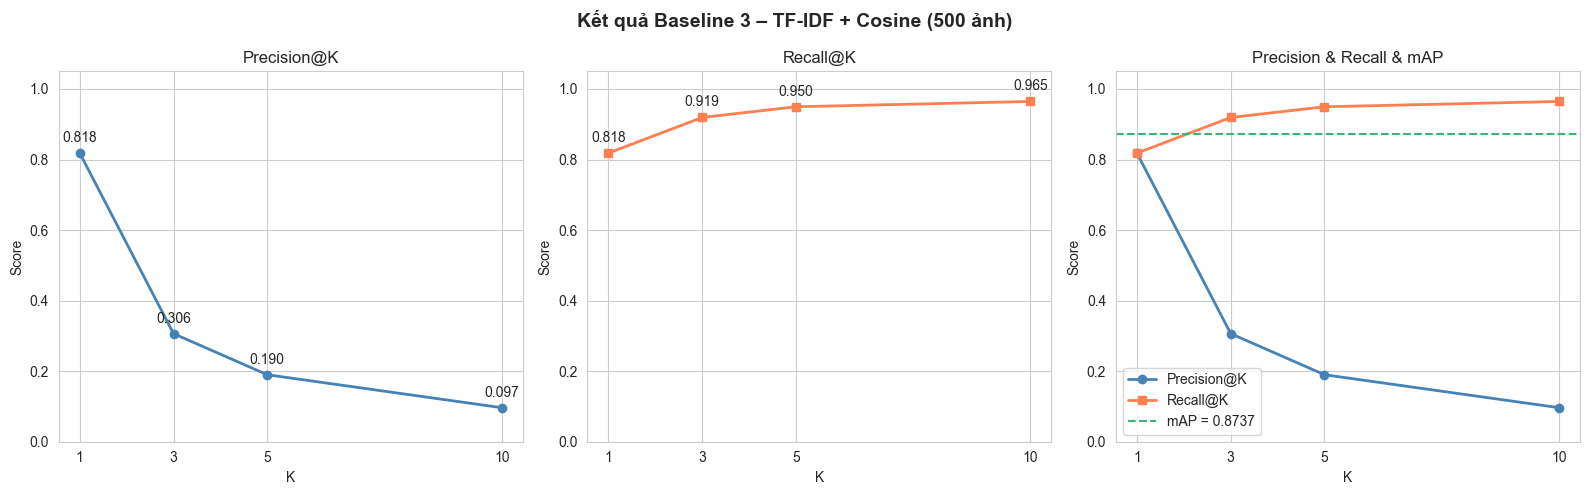

Đã lưu biểu đồ: ../results/bieu_do_metrics_baseline3_tfidf.png


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Kết quả Baseline 3 – TF-IDF + Cosine (500 ảnh)', fontsize=14, fontweight='bold')
k_vals = metrics_df['K'].tolist()

axes[0].plot(k_vals, metrics_df['Precision@K'], marker='o', color='steelblue', linewidth=2)
for x, y in zip(k_vals, metrics_df['Precision@K']):
    axes[0].annotate(f'{y:.3f}', (x, y), textcoords='offset points', xytext=(0, 8), ha='center')
axes[0].set_title('Precision@K')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Score')
axes[0].set_xticks(k_vals)
axes[0].set_ylim(0, 1.05)

axes[1].plot(k_vals, metrics_df['Recall@K'], marker='s', color='coral', linewidth=2)
for x, y in zip(k_vals, metrics_df['Recall@K']):
    axes[1].annotate(f'{y:.3f}', (x, y), textcoords='offset points', xytext=(0, 8), ha='center')
axes[1].set_title('Recall@K')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Score')
axes[1].set_xticks(k_vals)
axes[1].set_ylim(0, 1.05)

axes[2].plot(k_vals, metrics_df['Precision@K'], marker='o', label='Precision@K', color='steelblue', linewidth=2)
axes[2].plot(k_vals, metrics_df['Recall@K'], marker='s', label='Recall@K', color='coral', linewidth=2)
axes[2].axhline(y=mAP, color='mediumseagreen', linestyle='--', linewidth=1.5, label=f'mAP = {mAP:.4f}')
axes[2].set_title('Precision & Recall & mAP')
axes[2].set_xlabel('K')
axes[2].set_ylabel('Score')
axes[2].set_xticks(k_vals)
axes[2].set_ylim(0, 1.05)
axes[2].legend()

plt.tight_layout()
plt.savefig(os.path.join(RESULTS, 'bieu_do_metrics_baseline3_tfidf.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Đã lưu biểu đồ: {os.path.join(RESULTS, "bieu_do_metrics_baseline3_tfidf.png")}')


## 7. Bảng so sánh 3 Baseline


In [21]:
from io import StringIO

def load_resnet_metrics():
    resnet_path = os.path.join(RESULTS, 'avg_metrics_500.csv')
    if not os.path.exists(resnet_path):
        return 0.7755, 0.7273, 0.8939
    raw = open(resnet_path, encoding='utf-8').read()
    if '<<<<<<<' in raw:
        block = raw.split('<<<<<<< HEAD')[1].split('=======')[0].strip()
        df = pd.read_csv(StringIO(block))
    else:
        df = pd.read_csv(resnet_path)
    return (
        float(df['mAP'].iloc[0]),
        float(df.loc[df['K'] == 1, 'Precision@K'].iloc[0]),
        float(df.loc[df['K'] == 10, 'Recall@K'].iloc[0]),
    )

def load_metric_file(filename):
    p = os.path.join(RESULTS, filename)
    if not os.path.exists(p):
        return None
    df = pd.read_csv(p)
    return {
        'mAP': float(df['mAP'].iloc[0]),
        'Precision@1': float(df.loc[df['K'] == 1, 'Precision@K'].iloc[0]),
        'Recall@10': float(df.loc[df['K'] == 10, 'Recall@K'].iloc[0]),
    }

resnet_map, p1_resnet, r10_resnet = load_resnet_metrics()
rows_compare = [
    {'Baseline': 'Baseline 1 – ResNet50', 'Phương pháp': 'Deep feature + Cosine',
     'mAP': resnet_map, 'Precision@1': p1_resnet, 'Recall@10': r10_resnet},
    {'Baseline': 'Baseline 3 – TF-IDF', 'Phương pháp': 'Title TF-IDF + Cosine',
     'mAP': mAP,
     'Precision@1': float(metrics_df.loc[metrics_df['K'] == 1, 'Precision@K'].iloc[0]),
     'Recall@10': float(metrics_df.loc[metrics_df['K'] == 10, 'Recall@K'].iloc[0])},
]

for fname, bname, bmethod in [('avg_metrics_500_phash.csv', 'Baseline 2 – pHash', 'Perceptual Hash + Hamming')]:
    m = load_metric_file(fname)
    if m:
        rows_compare.append({'Baseline': bname, 'Phương pháp': bmethod, **m})

compare_df = pd.DataFrame(rows_compare).drop_duplicates(subset=['Baseline']).sort_values('mAP', ascending=False)
compare_df = compare_df.reset_index(drop=True)

print('\n=== BẢNG SO SÁNH CÁC BASELINE ===')
print(compare_df.to_string(index=False))
best = compare_df.iloc[0]
print(f'\nKết luận: {best["Baseline"]} đạt mAP cao nhất ({best["mAP"]:.4f}) trên tập 500 ảnh.')

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(compare_df))
w = 0.25
ax.bar(x - w, compare_df['mAP'], width=w, label='mAP', color='mediumseagreen')
ax.bar(x, compare_df['Precision@1'], width=w, label='Precision@1', color='steelblue')
ax.bar(x + w, compare_df['Recall@10'], width=w, label='Recall@10', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(compare_df['Baseline'], rotation=12, ha='right')
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('So sánh Baseline trên tập 500 ảnh')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, 'bieu_do_so_sanh_3_baseline.png'), dpi=150, bbox_inches='tight')
plt.show()
compare_df.to_csv(os.path.join(RESULTS, 'compare_3_baselines.csv'), index=False)
print(f'Đã lưu: {os.path.join(RESULTS, "compare_3_baselines.csv")}')


KeyError: 'mAP'

**Kết luận tổng hợp:**

| Baseline | Tín hiệu | Điểm mạnh |
|----------|----------|-----------|
| ResNet50 | Hình ảnh (deep) | Visual semantics |
| pHash | Hình ảnh (hash) | Nhanh, không GPU |
| TF-IDF | Văn bản | Sản phẩm trùng tên |

Phương pháp có **mAP cao nhất** trong `compare_3_baselines.csv` là hiệu quả nhất trên tập 500 ảnh này. Với visual search thuần ảnh, **ResNet50** thường dẫn đầu; TF-IDF hữu ích khi bổ sung re-rank đa phương thức (ảnh + text).
